# Generate parameter sweeps
code from `notebooks-part2/Part1_Block2_ParameterSensitivity.ipynb`

In [30]:
import sys, json, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'data' / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / 'data' / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'

EXP_ID     = 1
SITE_ID    = 1
SIGNAL_COL = 'ERKKTR_ratio'

def run_block(exp, site, signal, radius, window, quantile, threshold=None):
    """Run the single-block script and return the parsed summary dict."""
    tag   = f'exp_{exp}_site_{site}_{signal}_r{radius}_w{window}_q{int(quantile*100)}'
    outdir = OUTPUT_ROOT / tag
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path',            str(DATA_PATH),
        '--meta-path',            str(META_PATH),
        '--exp-id',               str(exp),
        '--site-id',              str(site),
        '--signal-col',           signal,
        '--spatial-radius',       str(radius),
        '--future-window-frames', str(window),
        '--jump-quantile',        str(quantile),
        '--output-dir',           str(outdir.parent),
    ]
    if threshold is not None:
        cmd += ['--jump-threshold', str(threshold)]
    subprocess.run(cmd, capture_output=True)
    summary_path = outdir / 'summary.json'
    if not summary_path.exists():
        # fallback: script may have used default output naming
        summary_path = OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}' / 'summary.json'
    with open(summary_path) as f:
        return json.load(f)

print('Setup complete.')

Setup complete.


In [43]:
# radii = range(15, 200, 15)

# rows_r = []
# for r in radii:
#     print(f'  running r={r} …', end=' ', flush=True)
#     outdir = OUTPUT_ROOT / f'sweep_r{r}'
#     cmd = [
#         sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
#         '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
#         '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
#         '--signal-col', SIGNAL_COL,
#         '--spatial-radius', str(r),
#         '--future-window-frames', '3',
#         '--jump-quantile', '0.9',
#         '--output-dir', str(outdir),
#     ]
#     subprocess.run(cmd, capture_output=True)
#     sp = next((outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}').glob('summary.json'), None)
#     if sp is None:
#         sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
#     with open(sp) as f:
#         s = json.load(f)
# rows_r.append({
#     'r': r,
#     '|E_sp|': s['n_spatial_edges'],
#     'θ': round(s['jump_threshold'], 4),
#     'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
#     'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
#     'RR': round(s['relative_risk'], 4),
#     'RD': round(s['risk_difference'], 4),
# })
# print('done')

# df_r = pd.DataFrame(rows_r).set_index('r')
# # df_r

  running r=60 … done


In [32]:
# windows = [1, 3, 6, 12]
# rows_w = []
# for w in windows:
#     print(f'  running W={w} …', end=' ', flush=True)
#     outdir = OUTPUT_ROOT / f'sweep_w{w}'
#     cmd = [
#         sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
#         '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
#         '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
#         '--signal-col', SIGNAL_COL,
#         '--spatial-radius', '60',
#         '--future-window-frames', str(w),
#         '--jump-quantile', '0.9',
#         '--output-dir', str(outdir),
#     ]
#     subprocess.run(cmd, capture_output=True)
#     sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
#     with open(sp) as f:
#         s = json.load(f)
#     rows_w.append({
#         'W (frames)': w,
#         'W (min)': w * 5,
#         'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
#         'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
#         'RR': round(s['relative_risk'], 4),
#         'RD': round(s['risk_difference'], 4),
#     })
#     print('done')

# df_w = pd.DataFrame(rows_w).set_index('W (frames)')
# # df_w

In [33]:
# quantiles = [0.70, 0.80, 0.90, 0.95]
# rows_q = []
# for q in quantiles:
#     print(f'  running q={q} …', end=' ', flush=True)
#     outdir = OUTPUT_ROOT / f'sweep_q{int(q*100)}'
#     cmd = [
#         sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
#         '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
#         '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
#         '--signal-col', SIGNAL_COL,
#         '--spatial-radius', '60',
#         '--future-window-frames', '3',
#         '--jump-quantile', str(q),
#         '--output-dir', str(outdir),
#     ]
#     subprocess.run(cmd, capture_output=True)
#     sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
#     with open(sp) as f:
#         s = json.load(f)

#     # Also load nodes to get the fraction of jump events
#     nodes_path = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'nodes.csv.gz'
#     nodes_q = pd.read_csv(nodes_path)
#     jump_frac = nodes_q['jump_event'].mean()

#     rows_q.append({
#         'q': q,
#         'θ_q': round(s['jump_threshold'], 4),
#         '% jump nodes': round(jump_frac * 100, 1),
#         'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
#         'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
#         'RR': round(s['relative_risk'], 4),
#     })
#     print('done')

# df_q = pd.DataFrame(rows_q).set_index('q')
# # df_q

# Saptial radius ($r$) sweep

## Load data from parameter sweeps

In [65]:
import json
import re

summary_files = sorted(OUTPUT_ROOT.glob("sweep_r*/exp_1_site_1_ERKKTR_ratio/summary.json"))

rows = []
for p in summary_files:
    with open(p) as f:
        d = json.load(f)
    m = re.search(r"sweep_r(\d+)", str(p))
    d["r"] = int(m.group(1)) if m else None
    rows.append(d)

df_sweeps = pd.DataFrame(rows).sort_values("r").set_index("r")
df_sweeps['average_n_neighbors'] = df_sweeps['n_spatial_edges'] / df_sweeps['n_nodes'] * 2
df_sweeps

,exp_id,site_id,mutation,signal_col,spatial_radius,future_window_frames,jump_threshold,n_nodes,n_spatial_edges,n_temporal_edges,n_tracks,n_frames,n_exposed_nodes,n_unexposed_nodes,future_jump_rate_if_neighbor_jumps_now,future_jump_rate_if_no_neighbor_jumps_now,risk_difference,relative_risk,average_n_neighbors
r,,,,,,,,,,,,,,,,,,,
15,1,1,WT,ERKKTR_ratio,15.0,3,0.036543,356632,8168,354834,1798,258,1086,355546,0.327808,0.097430,0.230378,3.364539,0.045806
30,1,1,WT,ERKKTR_ratio,30.0,3,0.036543,356632,508839,354834,1798,258,43171,313461,0.179704,0.086898,0.092806,2.067998,2.853580
45,1,1,WT,ERKKTR_ratio,45.0,3,0.036543,356632,1304572,354834,1798,258,94198,262434,0.149653,0.079639,0.070014,1.879139,7.316068
60,1,1,WT,ERKKTR_ratio,60.0,3,0.036543,356632,2389504,354834,1798,258,146620,210012,0.131455,0.074867,0.056588,1.755850,13.400390
75,1,1,WT,ERKKTR_ratio,75.0,3,0.036543,356632,3761864,354834,1798,258,196896,159736,0.119352,0.071975,0.047377,1.658247,21.096615
90,1,1,WT,ERKKTR_ratio,90.0,3,0.036543,356632,5401402,354834,1798,258,239638,116994,0.111981,0.069764,0.042217,1.605140,30.291180
105,1,1,WT,ERKKTR_ratio,105.0,3,0.036543,356632,7283073,354834,1798,258,274148,82484,0.106851,0.069153,0.037698,1.545144,40.843632
120,1,1,WT,ERKKTR_ratio,120.0,3,0.036543,356632,9409711,354834,1798,258,300523,56109,0.103323,0.070327,0.032996,1.469174,52.769864
135,1,1,WT,ERKKTR_ratio,135.0,3,0.036543,356632,11760201,354834,1798,258,319585,37047,0.101194,0.071720,0.029474,1.410961,65.951463


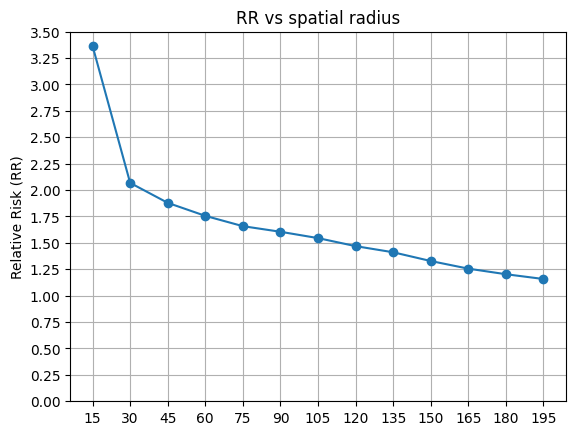

In [66]:
import matplotlib.pyplot as plt

plt.plot(df_sweeps.index, df_sweeps['relative_risk'], marker='o')
plt.grid()
plt.title("RR vs spatial radius")
plt.yticks(np.arange(0, df_sweeps['relative_risk'].max() + 0.25, 0.25))
plt.xticks(df_sweeps.index)
plt.ylabel("Relative Risk (RR)")
plt.show()

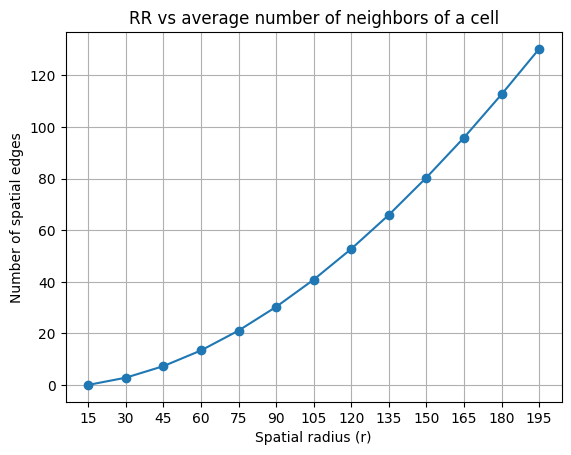

In [67]:
import matplotlib.pyplot as plt

plt.plot(df_sweeps.index, df_sweeps['average_n_neighbors'], marker='o')
plt.grid()
plt.title("RR vs average number of neighbors of a cell")
plt.xlabel("Spatial radius (r)")
plt.xticks(df_sweeps.index)
plt.ylabel("Number of spatial edges")
plt.show()

In [68]:
df_only_selected_r = df_sweeps.loc[[30, 60, 90, 150]]
df_only_selected_r

,exp_id,site_id,mutation,signal_col,spatial_radius,future_window_frames,jump_threshold,n_nodes,n_spatial_edges,n_temporal_edges,n_tracks,n_frames,n_exposed_nodes,n_unexposed_nodes,future_jump_rate_if_neighbor_jumps_now,future_jump_rate_if_no_neighbor_jumps_now,risk_difference,relative_risk,average_n_neighbors
r,,,,,,,,,,,,,,,,,,,
30,1,1,WT,ERKKTR_ratio,30.0,3,0.036543,356632,508839,354834,1798,258,43171,313461,0.179704,0.086898,0.092806,2.067998,2.853580
60,1,1,WT,ERKKTR_ratio,60.0,3,0.036543,356632,2389504,354834,1798,258,146620,210012,0.131455,0.074867,0.056588,1.755850,13.400390
90,1,1,WT,ERKKTR_ratio,90.0,3,0.036543,356632,5401402,354834,1798,258,239638,116994,0.111981,0.069764,0.042217,1.605140,30.291180
150,1,1,WT,ERKKTR_ratio,150.0,3,0.036543,356632,14339412,354834,1798,258,332701,23931,0.099786,0.075133,0.024654,1.328134,80.415734


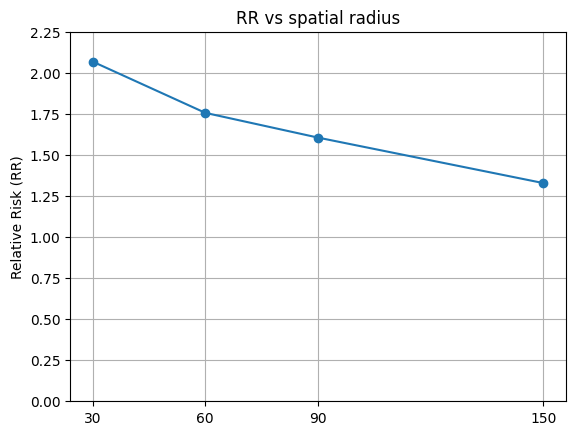

In [69]:
import matplotlib.pyplot as plt

plt.plot(df_only_selected_r.index, df_only_selected_r['relative_risk'], marker='o')
plt.grid()
plt.title("RR vs spatial radius")
plt.yticks(np.arange(0, df_only_selected_r['relative_risk'].max() + 0.25, 0.25))
plt.xticks(df_only_selected_r.index)
plt.ylabel("Relative Risk (RR)")
plt.show()

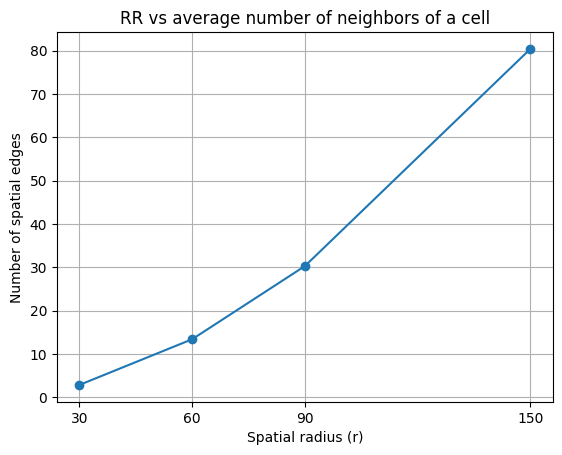

In [70]:
import matplotlib.pyplot as plt

plt.plot(df_only_selected_r.index, df_only_selected_r['average_n_neighbors'], marker='o')
plt.grid()
plt.title("RR vs average number of neighbors of a cell")
plt.xlabel("Spatial radius (r)")
plt.xticks(df_only_selected_r.index)
plt.ylabel("Number of spatial edges")
plt.show()